In [1]:
import pandas as pd
import numpy as np
import time
import warnings
warnings.filterwarnings("ignore")

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier,
    ExtraTreesClassifier,
    HistGradientBoostingClassifier
)
from sklearn.svm import SVC

from sklearn.neural_network import MLPClassifier

from imblearn.over_sampling import SMOTE


In [2]:
# Load the dataset
df = pd.read_csv("./archive/station_hour.csv")
df = df.dropna(subset=["AQI_Bucket"])
print("Shape after dropping missing target:", df.shape)

Shape after dropping missing target: (2018893, 16)


In [3]:
features = [
    "PM2.5", "PM10", "NO", "NO2", "NOx", "NH3",
    "CO", "SO2", "O3", "Benzene", "Toluene", "Xylene"
]

df = df[features + ["AQI_Bucket"]]


In [4]:
df[features] = df[features].fillna(df[features].median())


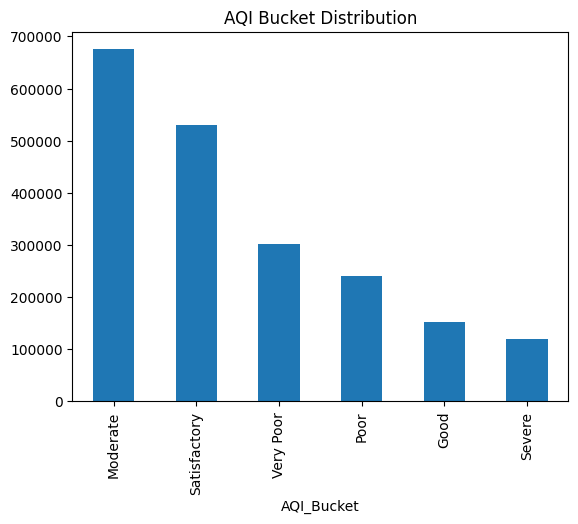

In [5]:
plt.figure()
df["AQI_Bucket"].value_counts().plot(kind="bar")
plt.title("AQI Bucket Distribution")
plt.show()


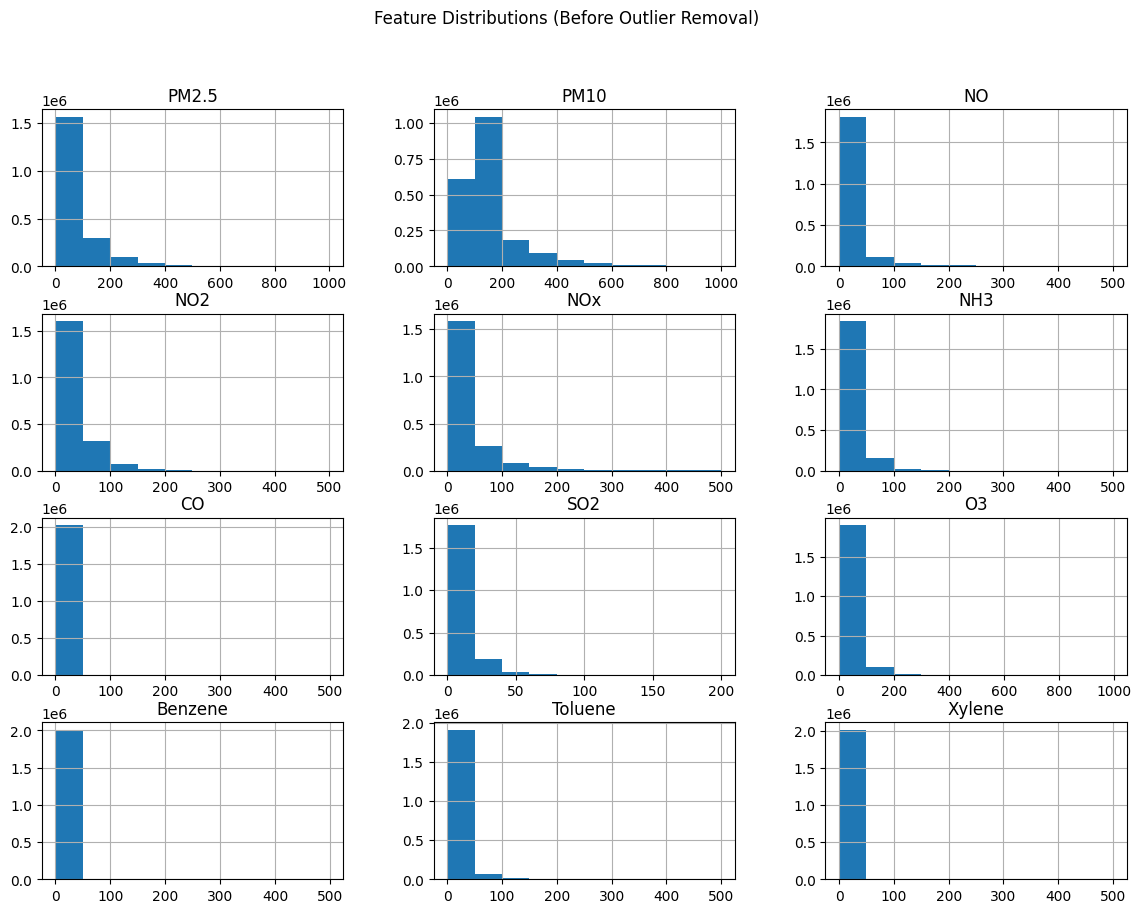

In [6]:
df[features].hist(figsize=(14,10))
plt.suptitle("Feature Distributions (Before Outlier Removal)")
plt.show()


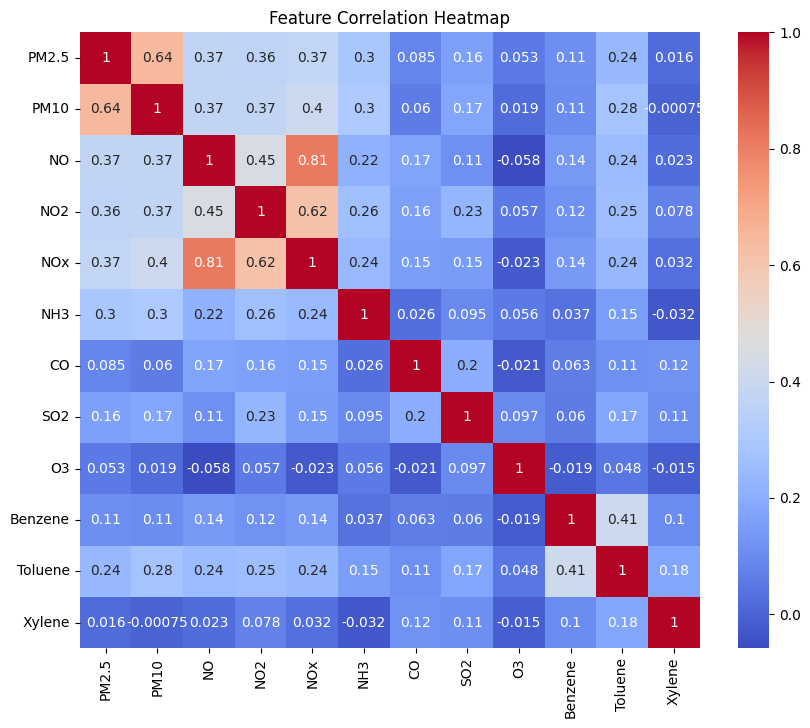

In [7]:
plt.figure(figsize=(10,8))
sns.heatmap(df[features].corr(), cmap="coolwarm", annot=True)
plt.title("Feature Correlation Heatmap")
plt.show()


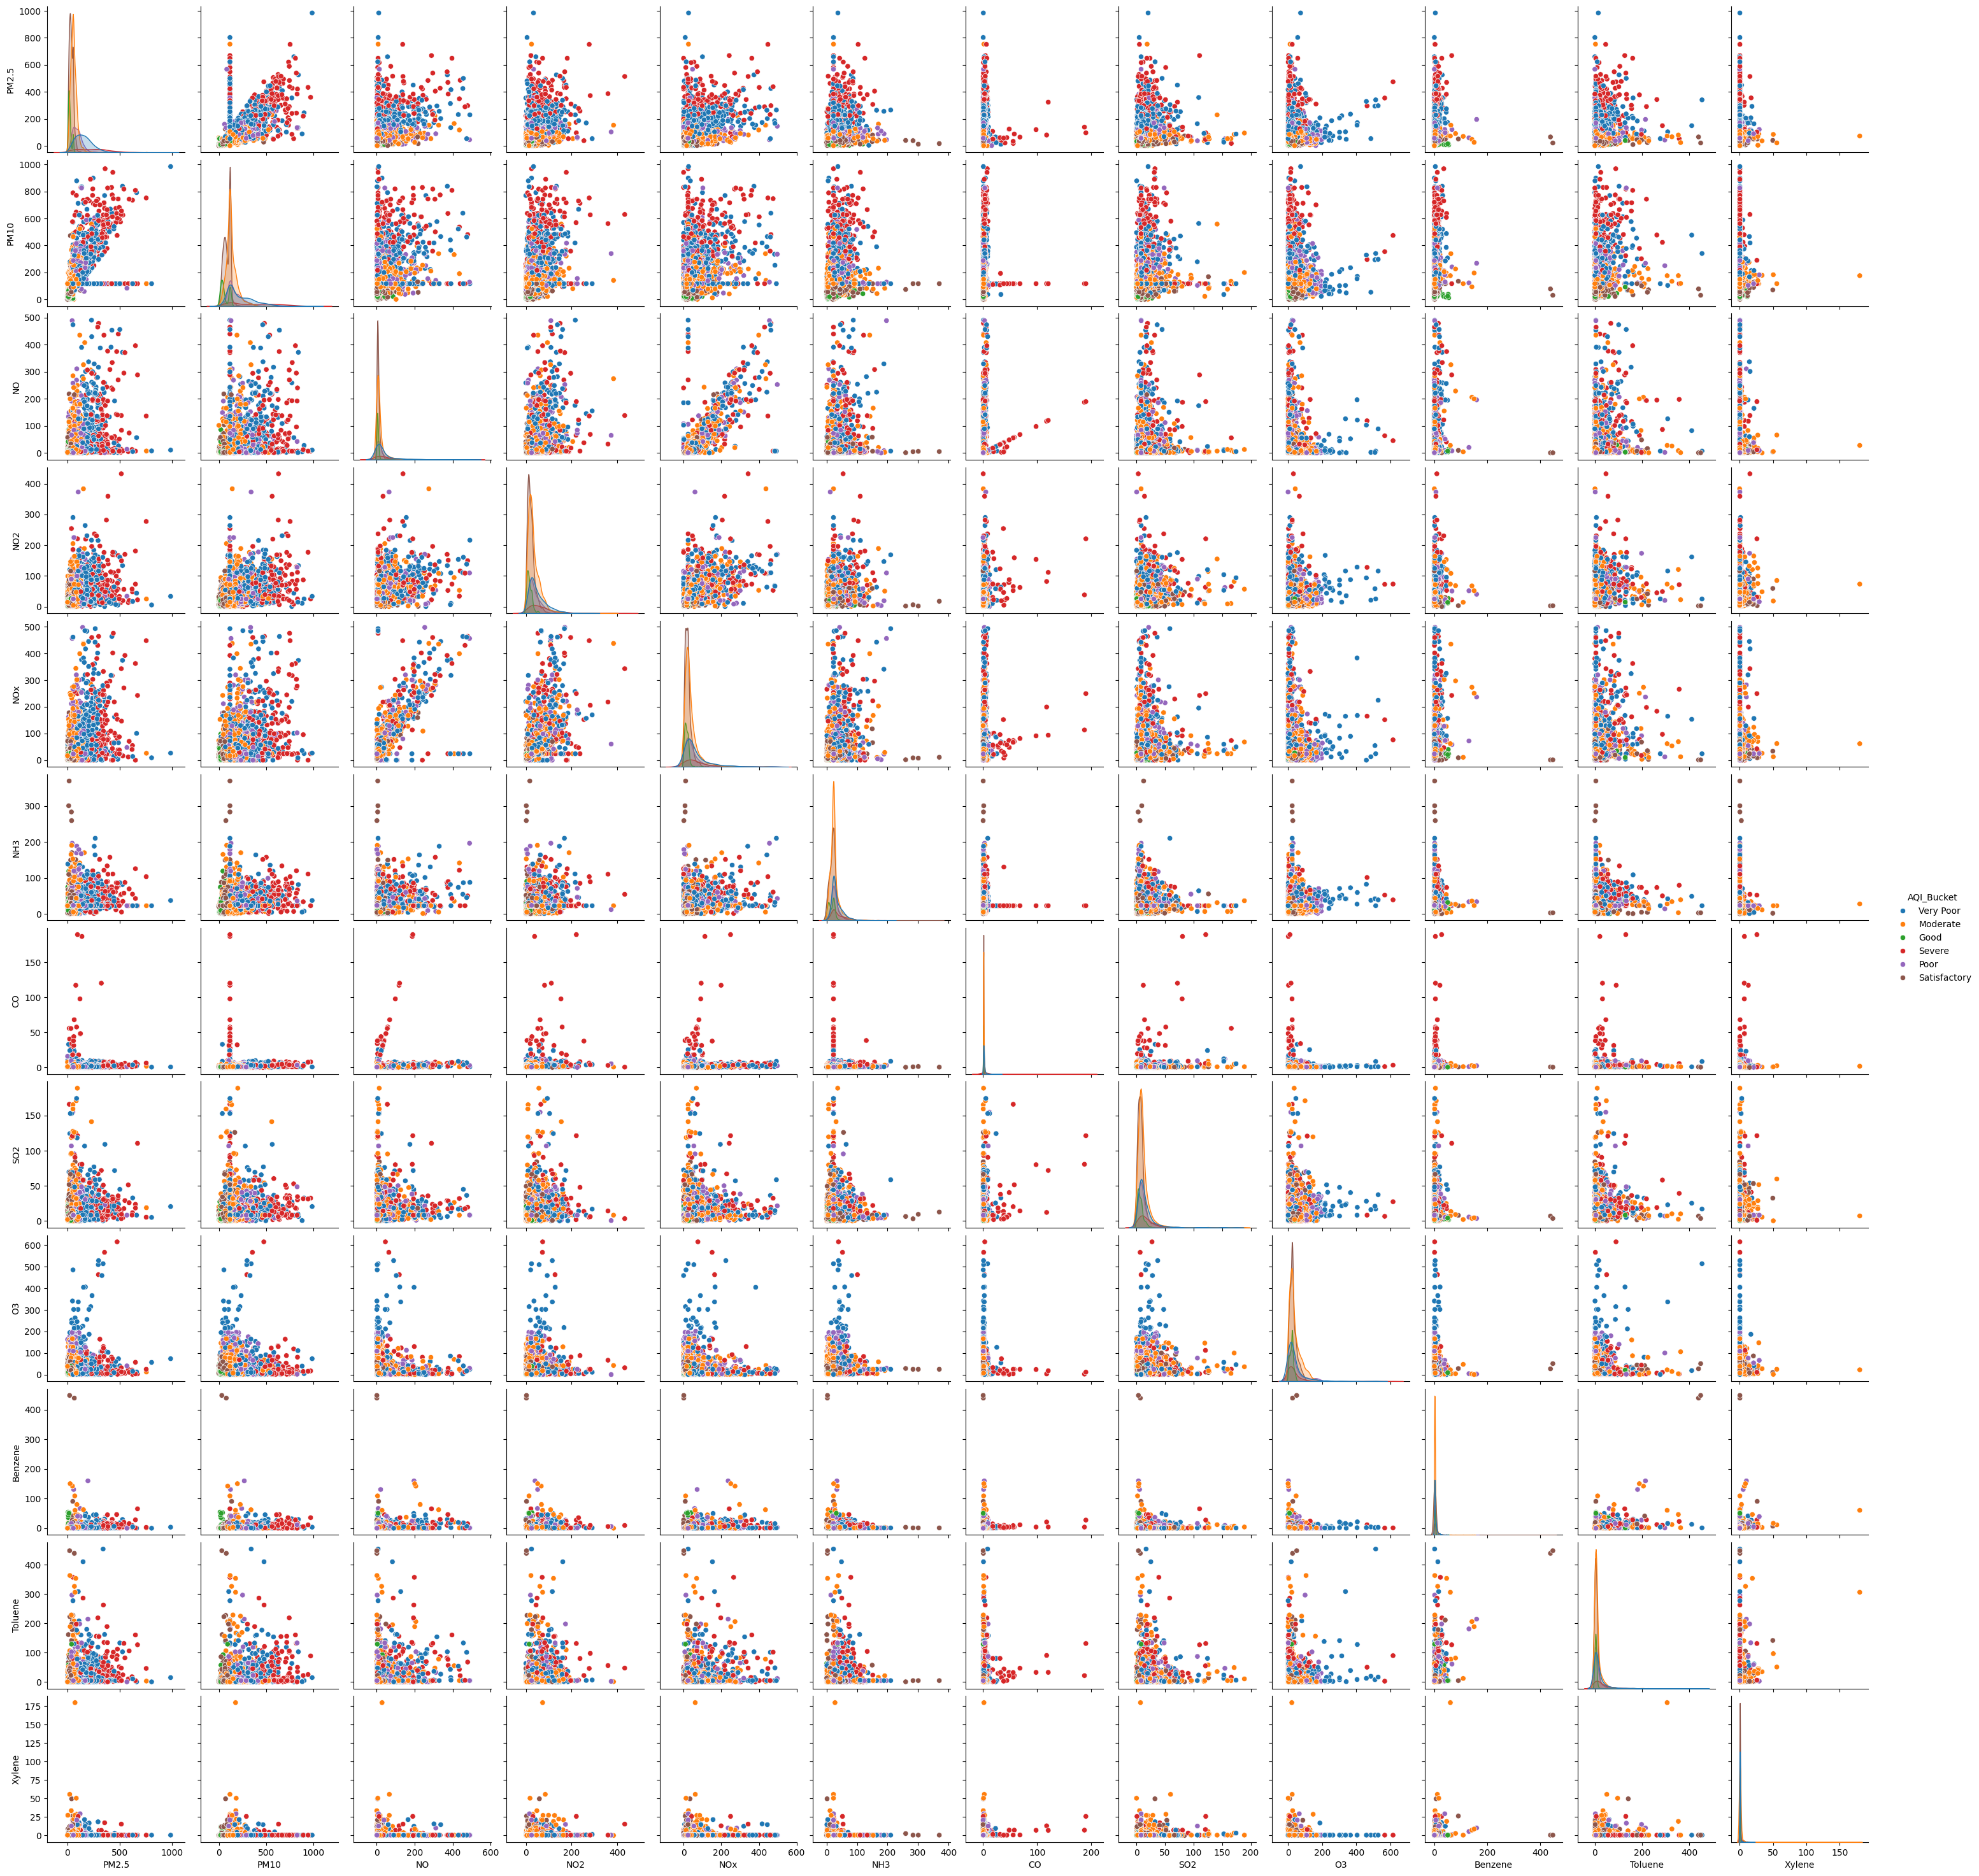

In [8]:
sns.pairplot(df.sample(5000), hue="AQI_Bucket", diag_kind="kde")
plt.show()

In [9]:
X = df[features]
y = df["AQI_Bucket"]

le = LabelEncoder()
y_enc = le.fit_transform(y)


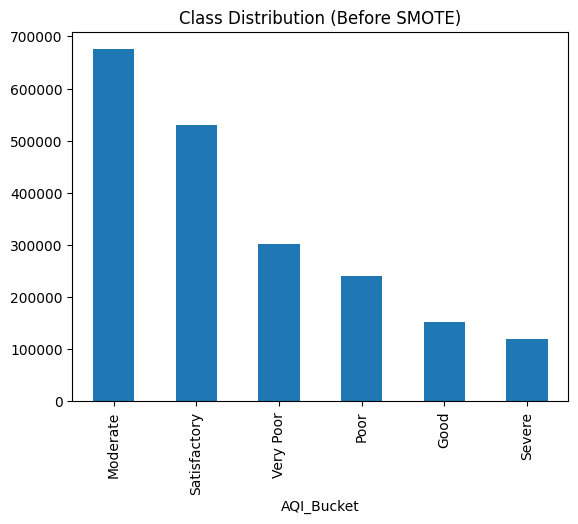

In [10]:
plt.figure()
pd.Series(y).value_counts().plot(kind="bar")
plt.title("Class Distribution (Before SMOTE)")
plt.show()


In [11]:
smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X, y_enc)


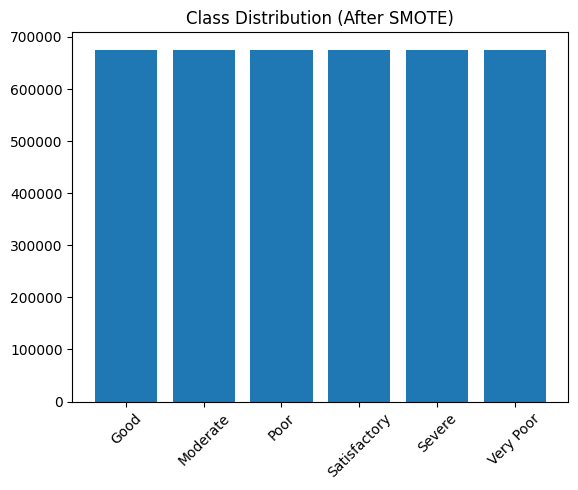

In [12]:
unique, counts = np.unique(y_smote, return_counts=True)

plt.figure()
plt.bar(le.inverse_transform(unique), counts)
plt.title("Class Distribution (After SMOTE)")
plt.xticks(rotation=45)
plt.show()


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X_smote, y_smote,
    test_size=0.2,
    stratify=y_smote,
    random_state=42
)


In [14]:
gb_model = HistGradientBoostingClassifier(
    max_depth=8,
    learning_rate=0.08,
    max_iter=300,
    random_state=42
)

gb_model.fit(X_train, y_train)


HistGradientBoostingClassifier(learning_rate=0.08, max_depth=8, max_iter=300,
                               random_state=42)

In [15]:
y_pred_gb = gb_model.predict(X_test)

print("Gradient Boosting Accuracy:", accuracy_score(y_test, y_pred_gb))
print(classification_report(y_test, y_pred_gb, target_names=le.classes_))


Gradient Boosting Accuracy: 0.6287527314477599
              precision    recall  f1-score   support

        Good       0.78      0.87      0.82    135001
    Moderate       0.57      0.53      0.55    135001
        Poor       0.51      0.52      0.51    135002
Satisfactory       0.57      0.65      0.61    135002
      Severe       0.76      0.71      0.73    135002
   Very Poor       0.57      0.50      0.53    135002

    accuracy                           0.63    810010
   macro avg       0.63      0.63      0.63    810010
weighted avg       0.63      0.63      0.63    810010



In [16]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    n_jobs=-1,
    random_state=42
)

rf_model.fit(X_train, y_train)


RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)

In [17]:
y_pred_rf = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))


Random Forest Accuracy: 0.8277638547672251
              precision    recall  f1-score   support

        Good       0.84      0.97      0.90    135001
    Moderate       0.76      0.67      0.71    135001
        Poor       0.80      0.82      0.81    135002
Satisfactory       0.77      0.78      0.78    135002
      Severe       0.92      0.93      0.93    135002
   Very Poor       0.86      0.80      0.83    135002

    accuracy                           0.83    810010
   macro avg       0.83      0.83      0.83    810010
weighted avg       0.83      0.83      0.83    810010



In [19]:
import pickle

with open("rf_aqi_model.pkl", "wb") as f:
    pickle.dump(rf_model, f)